# Random Forest Early-Warning Model: Day 30

This notebook develops and evaluates a Random Forest classifier using the Day 30 early-warning dataset created for the SEAID Framework.

The model uses only information available on or before Day 30 of the course. Its performance will be compared with the Day 30 Logistic Regression and Decision Tree models to determine whether an ensemble learning approach improves early prediction of student outcomes.

## Notebook Objectives

1. Load and inspect the Day 30 modeling dataset.
2. Prepare the predictor variables and target variable.
3. Create training and testing datasets.
4. Train a Random Forest classifier.
5. Evaluate model performance using accuracy, precision, recall, F1 score, ROC-AUC, a classification report, a confusion matrix, and an ROC curve.
6. Examine feature importance.
7. Save the trained model and evaluation outputs.
8. Compare the Random Forest results with the Logistic Regression and Decision Tree models.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"

DATA_PATH = DATA_DIR / "final_modeling_dataset_day30.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project directory: /content/drive/MyDrive/SEAID_Framework
Dataset path: /content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv
Dataset exists: True


## Load the Day 30 Modeling Dataset

This section loads the processed Day 30 early-warning dataset and verifies its dimensions and structure.

In [5]:
modeling_data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", modeling_data.shape)

display(modeling_data.head())

Dataset loaded successfully.
Dataset shape: (32593, 77)


,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,average_clicks_per_record,median_clicks_per_record,maximum_clicks_in_record,vle_records,active_days,unique_vle_activities,first_activity_day,last_activity_day,clicks_per_active_day,activity_span_days,clicks_per_vle_activity,log_total_clicks,assessments_completed,average_score,median_score,minimum_score,maximum_score,score_std,average_weight,total_weight_completed,first_submission_day,last_submission_day,banked_assessments,assessment_span_days,score_range,weighted_average_score,score_improvement,assessment_intensity,log_assessments_completed,date_registration,registered_before_start,registered_after_start,days_registered_before_start,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,6.424242,2.0,76.0,66.0,10.0,26.0,-5.0,30.0,42.400000,35.0,16.307692,6.052089,1.0,78.0,78.0,78.0,78.0,0.0,10.0,10.0,18.0,18.0,0.0,0.0,0.0,78.0,0.0,1.0,0.693147,-159.0,1,0,159.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,3.862500,2.5,19.0,160.0,19.0,34.0,-10.0,28.0,32.526316,38.0,18.176471,6.428105,1.0,70.0,70.0,70.0,70.0,0.0,10.0,10.0,22.0,22.0,0.0,0.0,0.0,70.0,0.0,1.0,0.693147,-53.0,1,0,53.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,3.697368,2.0,23.0,76.0,12.0,22.0,-10.0,12.0,23.416667,22.0,12.772727,5.641907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-92.0,1,0,92.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,3.552632,2.0,22.0,152.0,24.0,32.0,-10.0,30.0,22.500000,40.0,16.875000,6.293419,1.0,72.0,72.0,72.0,72.0,0.0,10.0,10.0,17.0,17.0,0.0,0.0,0.0,72.0,0.0,1.0,0.693147,-52.0,1,0,52.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,3.754967,2.0,22.0,151.0,24.0,34.0,-10.0,26.0,23.625000,36.0,16.676471,6.342121,1.0,69.0,69.0,69.0,69.0,0.0,10.0,10.0,26.0,26.0,0.0,0.0,0.0,69.0,0.0,1.0,0.693147,-176.0,1,0,176.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


## Prepare the Predictor Variables and Target

The binary target variable is `target_success`. The original `final_result` column is excluded because it directly contains the final course outcome and would create target leakage. The student identifier is also removed because it identifies records rather than representing a meaningful predictive feature.

In [6]:
TARGET = "target_success"

columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

X = modeling_data.drop(columns=columns_to_drop)
y = modeling_data[TARGET]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts().sort_index())

print("\nTarget proportions:")
display(
    y.value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Predictor matrix shape: (32593, 74)
Target vector shape: (32593,)

Target distribution:


,count
target_success,
0,17208
1,15385



Target proportions:


,proportion
target_success,
0,0.528
1,0.472


In [7]:
print("Target values:", sorted(y.unique()))
print("Missing target values:", y.isna().sum())
print("Duplicate predictor columns:", X.columns.duplicated().sum())

Target values: [np.int64(0), np.int64(1)]
Missing target values: 0
Duplicate predictor columns: 0


## Create Training and Testing Sets

The dataset is divided into training and testing subsets using an 80/20 split. Stratified sampling preserves the proportion of successful and unsuccessful students in both subsets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target proportions:")
display(y_test.value_counts(normalize=True).sort_index().round(3))

Training predictor shape: (26074, 74)
Testing predictor shape: (6519, 74)

Training target proportions:


,proportion
target_success,
0,0.528
1,0.472



Testing target proportions:


,proportion
target_success,
0,0.528
1,0.472


## Create the Preprocessing Pipeline

Random Forest models do not require feature scaling. The preprocessing pipeline therefore handles missing values and encodes the remaining categorical variables before model training.

In [9]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical feature names:", categorical_features)

Numeric features: 72
Categorical features: 2
Categorical feature names: ['code_module', 'code_presentation']


In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Train the Random Forest Classifier

This section combines the preprocessing steps with a Random Forest classifier. The model uses 500 decision trees and all available processor cores during training.

In [11]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [12]:
y_pred = random_forest_pipeline.predict(X_test)

y_prob = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## Evaluate Model Performance

This section evaluates the Random Forest classifier using accuracy, precision, recall, F1 score, and ROC-AUC. These metrics will be compared directly with the Logistic Regression and Decision Tree models.

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    }
)

display(metrics_df)

,Metric,Value
0,Accuracy,0.764841
1,Precision,0.723250
2,Recall,0.812805
3,F1 Score,0.765417
4,ROC-AUC,0.848734


In [14]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.7648
Precision: 0.7233
Recall:    0.8128
F1 Score:  0.7654
ROC-AUC:   0.8487


## Classification Report

The classification report provides precision, recall, F1 score, and support for each outcome class, offering a detailed assessment of the Random Forest classifier's predictive performance.

In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ]
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.81      0.72      0.76      3442
  Successful       0.72      0.81      0.77      3077

    accuracy                           0.76      6519
   macro avg       0.77      0.77      0.76      6519
weighted avg       0.77      0.76      0.76      6519



In [16]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        output_dict=True
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
Unsuccessful,0.811826,0.721964,0.764263,3442.000000
Successful,0.723250,0.812805,0.765417,3077.000000
accuracy,0.764841,0.764841,0.764841,0.764841
macro avg,0.767538,0.767384,0.764840,6519.000000
weighted avg,0.770018,0.764841,0.764808,6519.000000


## Confusion Matrix

The confusion matrix compares the Random Forest model's predicted outcomes with the observed student outcomes and summarizes correct and incorrect classifications.

In [17]:
confusion_matrix_values = confusion_matrix(
    y_test,
    y_pred
)

print(confusion_matrix_values)

[[2485  957]
 [ 576 2501]]


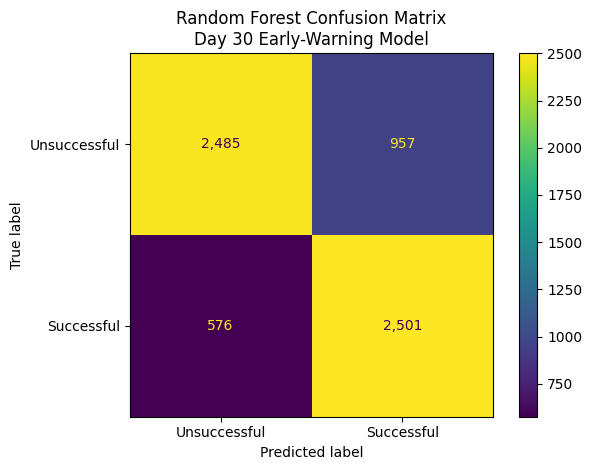

In [18]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "Random Forest Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve illustrates the Random Forest classifier's ability to distinguish between successful and unsuccessful students across all possible classification thresholds.

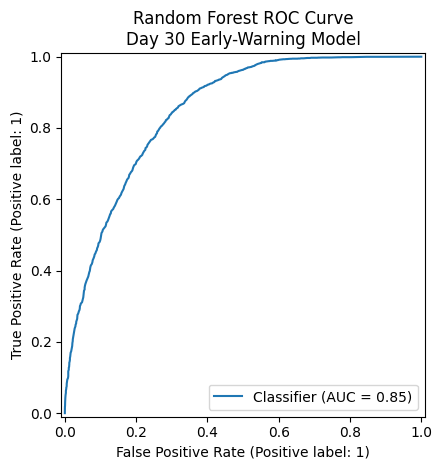

In [19]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Random Forest ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Feature Importance

Random Forest estimates feature importance by measuring the average reduction in impurity contributed by each predictor across all decision trees in the ensemble. Features with higher importance values have a greater influence on the model's predictions.

In [20]:
feature_names = (
    random_forest_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = (
    random_forest_pipeline.named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importance
        }
    )
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(feature_importance_df.head(20))

,Feature,Importance
12,num__last_activity_day,0.052127
15,num__clicks_per_vle_activity,0.043337
19,num__median_score,0.040543
16,num__log_total_clicks,0.040433
8,num__vle_records,0.039908
9,num__active_days,0.039443
18,num__average_score,0.038976
4,num__total_clicks,0.038233
14,num__activity_span_days,0.036915
5,num__average_clicks_per_record,0.035603


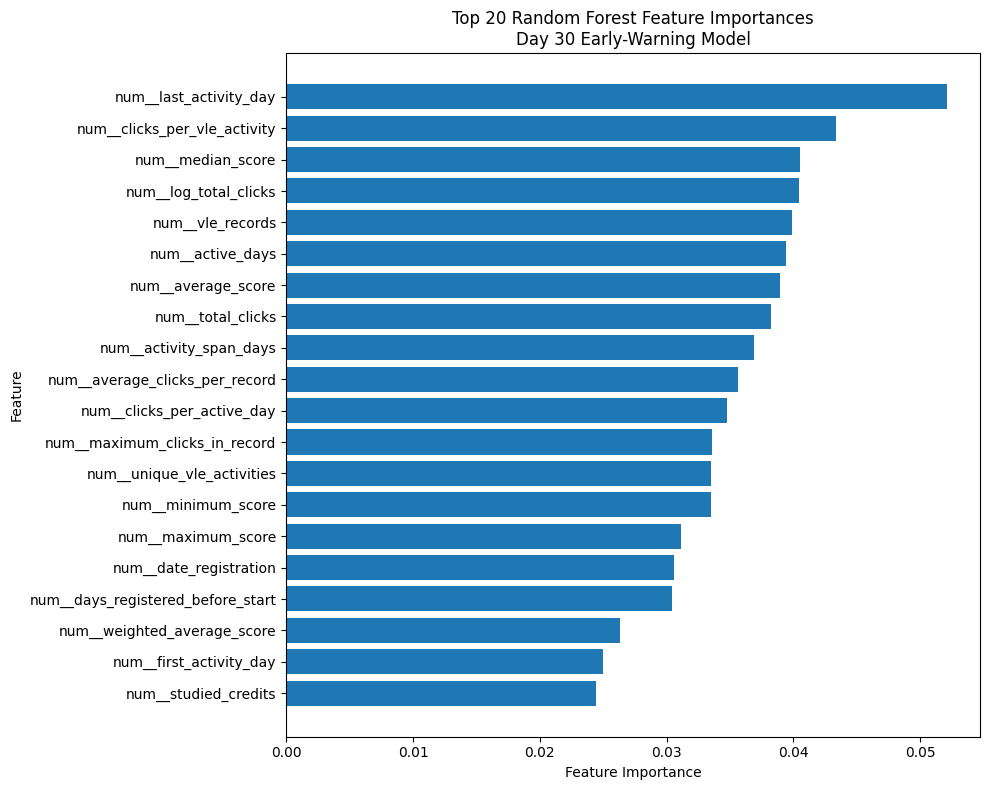

In [21]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Random Forest Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Feature Importance Interpretation

The Random Forest model identified **last_activity_day** as the single most influential predictor of student success by Day 30. This finding suggests that continued engagement later into the first month of the course is strongly associated with successful course completion.

Unlike the single Decision Tree model, the Random Forest distributed importance across a broader set of variables. Multiple indicators of student engagement—including clicks per VLE activity, total clicks, active days, VLE records, activity span, and average clicks per record—ranked among the most influential predictors. This pattern indicates that sustained participation in the online learning environment provides valuable information for identifying students who may require early intervention.

Assessment performance also contributed substantially to prediction. Variables such as median score, average score, minimum score, maximum score, and weighted average score all appeared among the twenty most important predictors, demonstrating that early academic achievement complements behavioral engagement when forecasting final course outcomes.

Registration-related variables, including date of registration and the number of days registered before the course began, also contributed to prediction, although their influence was smaller than engagement and assessment measures.

Overall, the feature importance results demonstrate that the Random Forest classifier captures meaningful relationships across multiple dimensions of student behavior rather than relying heavily on a single predictor. This balanced use of information likely contributed to the model's superior predictive performance compared with both the Logistic Regression and Decision Tree models.

## Save the Trained Model

The trained Random Forest model is saved for future prediction and comparison with other machine learning models developed within the SEAID Framework.

In [22]:
MODEL_PATH = MODEL_DIR / "random_forest_early_warning_day30.joblib"

joblib.dump(
    random_forest_pipeline,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/drive/MyDrive/SEAID_Framework/models/random_forest_early_warning_day30.joblib


## Save Evaluation Results

Save evaluation metrics, the classification report, and feature importance rankings for later comparison across models.

In [23]:
metrics_df.to_csv(
    OUTPUT_DIR / "random_forest_early_warning_metrics.csv",
    index=False
)

classification_report_df.to_csv(
    OUTPUT_DIR / "random_forest_classification_report.csv"
)

feature_importance_df.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv",
    index=False
)

print("Evaluation outputs saved.")

Evaluation outputs saved.


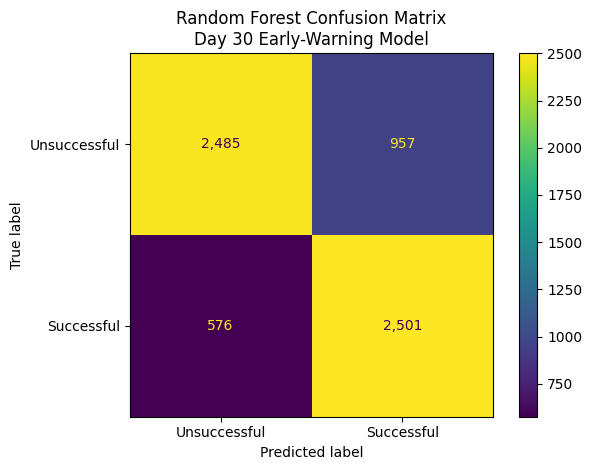

In [24]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "Random Forest Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

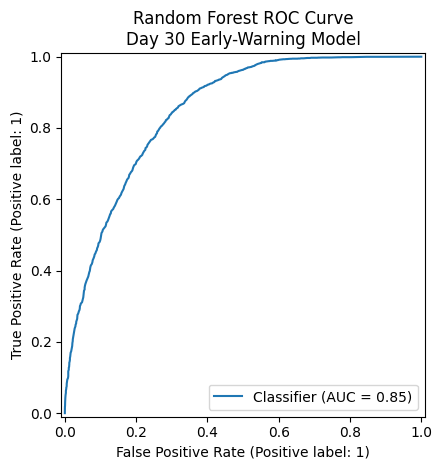

In [25]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Random Forest ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

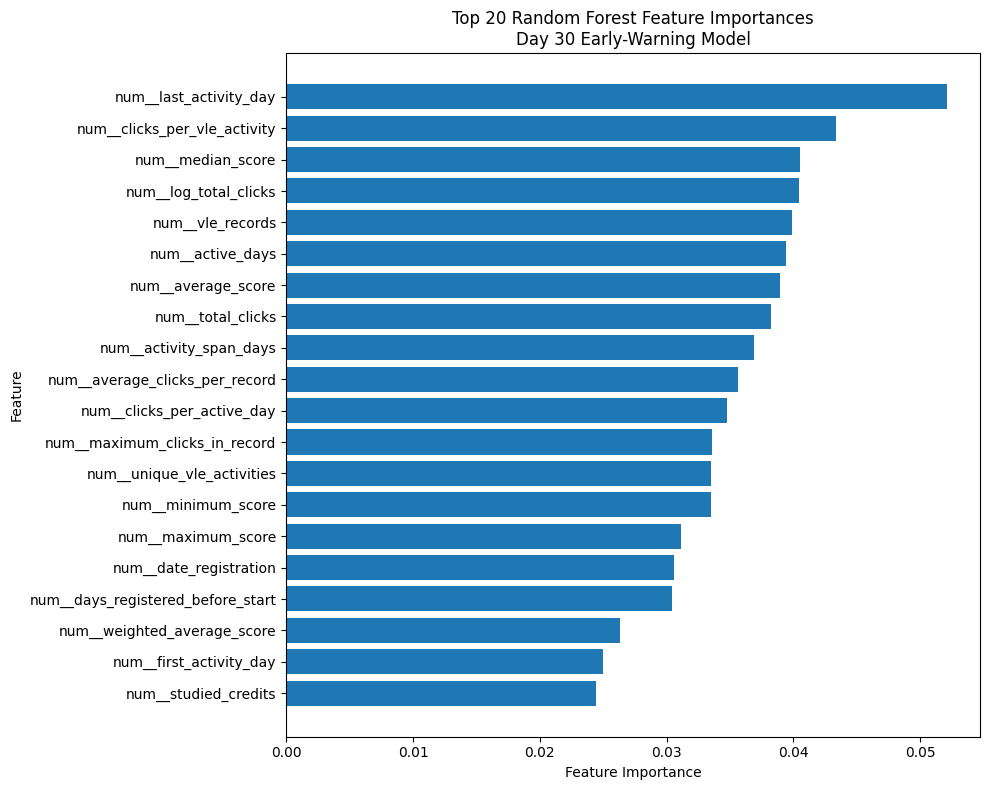

In [26]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Random Forest Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Notebook Summary

This notebook developed and evaluated a Random Forest classifier using Day 30 student engagement, assessment, and demographic data from the Open University Learning Analytics Dataset (OULAD).

## Model Performance

| Metric | Value |
|---------|-------|
| Accuracy | **76.5%** |
| Precision | **72.3%** |
| Recall | **81.3%** |
| F1 Score | **76.5%** |
| ROC-AUC | **0.8487** |

## Key Findings

- The Random Forest classifier achieved the strongest predictive performance among the models evaluated thus far.
- Student engagement variables remained the most influential predictors of final course success.
- Assessment performance and registration timing provided additional predictive value.
- The ensemble learning approach substantially improved predictive performance over the single Decision Tree model and also outperformed the Logistic Regression baseline across all evaluation metrics.

## Next Steps

The next notebook develops an XGBoost classifier using the same Day 30 dataset. Model performance from Logistic Regression, Decision Tree, Random Forest, and XGBoost will then be compared to identify the best-performing early-warning model for the SEAID Framework.